In [40]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Flatten,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [42]:
train_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "Cat and Dog/training_set/training_set"
)

test_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "Cat and Dog/test_set/test_set"
)

print("Training path exists:", os.path.exists(train_path))
print("Testing path exists:", os.path.exists(test_path))

Training path exists: True
Testing path exists: True


In [43]:
print("Training folders:", os.listdir(train_path))
print("Testing folders:", os.listdir(test_path))

Training folders: ['cats', 'dogs']
Testing folders: ['dogs', 'cats']


In [44]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 123

raw_train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

raw_test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = raw_train_dataset.class_names

print("Class names:", class_names)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [45]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = raw_train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = raw_test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Image preprocessing completed.")

Image preprocessing completed.


In [46]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


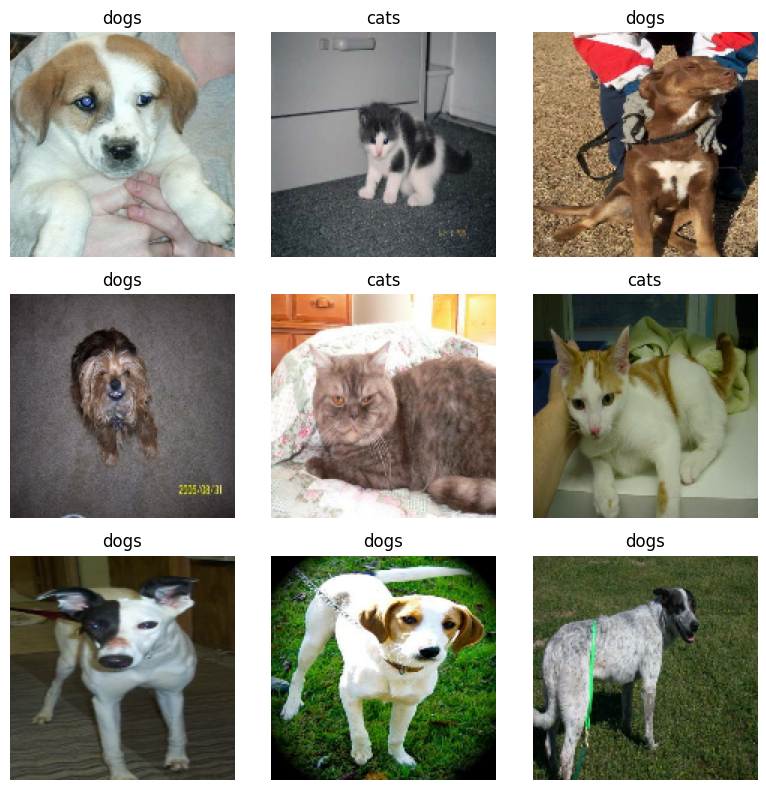

In [47]:
plt.figure(figsize=(8, 8))

for images, labels in raw_train_dataset.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))

        label_index = int(labels[index].numpy()[0])
        plt.title(class_names[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
basic_model = Sequential([
    Input(shape=(150, 150, 3)),
    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(1, activation="sigmoid")
])

basic_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │     2,160,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,160,065 (8.24 MB)

 Trainable params: 2,160,065 (8.24 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
basic_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Basic neural network compiled successfully.")

Basic neural network compiled successfully.


In [50]:
history_basic = basic_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 208ms/step - accuracy: 0.5203 - loss: 0.9859 - val_accuracy: 0.5007 - val_loss: 0.6932
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 56s 224ms/step - accuracy: 0.5003 - loss: 0.6946 - val_accuracy: 0.5002 - val_loss: 0.6932
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 203ms/step - accuracy: 0.5003 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6932
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 201ms/step - accuracy: 0.5003 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 201ms/step - accuracy: 0.5003 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931


In [51]:
basic_loss, basic_accuracy = basic_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Basic Neural Network Test Loss: {basic_loss:.4f}")
print(f"Basic Neural Network Test Accuracy: {basic_accuracy:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.5002 - loss: 0.6931
Basic Neural Network Test Loss: 0.6931
Basic Neural Network Test Accuracy: 0.5002


In [52]:
basic_model_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "basic_neural_network.keras"
)

basic_model.save(basic_model_path)

print("Basic neural network saved successfully.")
print("Saved at:", basic_model_path)

Basic neural network saved successfully.
Saved at: /content/drive/MyDrive/DLE305_Assessment_2/basic_neural_network.keras


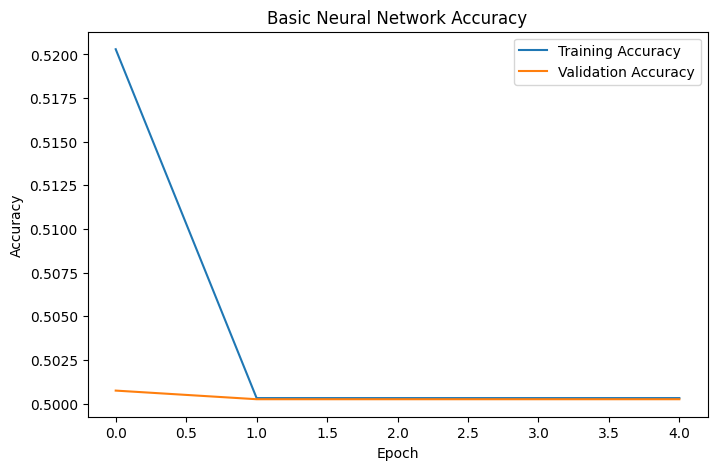

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_basic.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_basic.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic Neural Network Accuracy")
plt.legend()
plt.show()

In [54]:
cnn_one_model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

cnn_one_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │    11,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,215,873 (42.79 MB)

 Trainable params: 11,215,873 (42.79 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
cnn_one_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("One-layer CNN compiled successfully.")

One-layer CNN compiled successfully.


In [56]:
history_cnn_one = cnn_one_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 221s 869ms/step - accuracy: 0.5823 - loss: 0.7991 - val_accuracy: 0.6545 - val_loss: 0.6343
Epoch 2/5
 86/251 ━━━━━━━━━━━━━━━━━━━━ 2:17 834ms/step - accuracy: 0.6380 - loss: 0.6218

KeyboardInterrupt: 

In [ ]:
cnn_one_loss, cnn_one_accuracy = cnn_one_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"One-Layer CNN Test Loss: {cnn_one_loss:.4f}")
print(f"One-Layer CNN Test Accuracy: {cnn_one_accuracy:.4f}")

In [ ]:
cnn_one_model_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "cnn_one_convolution_layer.keras"
)

cnn_one_model.save(cnn_one_model_path)

print("One-layer CNN saved successfully.")
print("Saved at:", cnn_one_model_path)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn_one.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn_one.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("One-Layer CNN Accuracy")
plt.legend()
plt.show()

In [ ]:
cnn_two_model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(1, activation="sigmoid")
])

cnn_two_model.summary()

In [ ]:
cnn_two_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Two-layer CNN compiled successfully.")

In [ ]:
history_cnn_two = cnn_two_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

In [ ]:
cnn_two_loss, cnn_two_accuracy = cnn_two_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Two-Layer CNN Test Loss: {cnn_two_loss:.4f}")
print(f"Two-Layer CNN Test Accuracy: {cnn_two_accuracy:.4f}")

In [ ]:
cnn_two_model_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "cnn_two_convolution_layers.keras"
)

cnn_two_model.save(cnn_two_model_path)

print("Two-layer CNN saved successfully.")
print("Saved at:", cnn_two_model_path)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn_two.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn_two.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Two-Layer CNN Accuracy")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

bigger_cnn_model = Sequential([
    Input(shape=(150, 150, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

bigger_cnn_model.summary()

In [ ]:
bigger_cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Bigger CNN compiled successfully.")

In [ ]:
history_bigger_cnn = bigger_cnn_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

In [ ]:
bigger_cnn_loss, bigger_cnn_accuracy = bigger_cnn_model.evaluate(test_dataset)

print("Loss:", bigger_cnn_loss)
print("Accuracy:", bigger_cnn_accuracy)

In [ ]:
bigger_cnn_model.save(
    "/content/drive/MyDrive/DLE305_Assessment_2/bigger_cnn_model.keras"
)

print("Bigger CNN saved successfully.")

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Basic Neural Network",
        "CNN - One Convolution Layer",
        "CNN - Two Convolution Layers",
        "Bigger CNN"
    ],
    "Test Accuracy": [
        basic_accuracy,
        cnn_one_accuracy,
        cnn_two_accuracy,
        bigger_cnn_accuracy
    ],
    "Test Loss": [
        basic_loss,
        cnn_one_loss,
        cnn_two_loss,
        bigger_cnn_loss
    ]
})

results["Test Accuracy"] = results["Test Accuracy"].round(4)
results["Test Loss"] = results["Test Loss"].round(4)

results

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison of All Four Models")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Test Loss"]
)

plt.xlabel("Model")
plt.ylabel("Test Loss")
plt.title("Loss Comparison of All Four Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_basic.history["val_accuracy"],
    label="Basic NN"
)

plt.plot(
    history_cnn_one.history["val_accuracy"],
    label="CNN - One Layer"
)

plt.plot(
    history_cnn_two.history["val_accuracy"],
    label="CNN - Two Layers"
)

plt.plot(
    history_bigger_cnn.history["val_accuracy"],
    label="Bigger CNN"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

In [ ]:
best_model_row = results.loc[
    results["Test Accuracy"].idxmax()
]

print("Best-performing model:")
print(best_model_row)

In [ ]:
results_path = (
    "/content/drive/MyDrive/DLE305_Assessment_2/"
    "model_comparison_results.csv"
)

results.to_csv(results_path, index=False)

print("Comparison results saved successfully.")
print("Saved at:", results_path)

In [57]:
import os

project_folder = "/content/drive/MyDrive/DLE305_Assessment_2"

saved_files = os.listdir(project_folder)

for file_name in saved_files:
    if file_name.endswith((".keras", ".csv")):
        print(file_name)

cat_dog_cnn_model.keras
basic_neural_network.keras
cnn_one_convolution_layer.keras
cnn_two_convolution_layers.keras
bigger_cnn_model.keras
model_comparison_results.csv
